In [ ]:
%pip install tensorflow
%pip install opencv-python
%pip install matplotlib
%pip install numpy
%pip install scikit-learn

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay, confusion_matrix)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.utils import (to_categorical, image_dataset_from_directory)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

from google.colab import drive
from tensorflow.keras.callbacks import CSVLogger

LOAD DATASET

In [ ]:
drive.mount('/content/drive',force_remount=True)
!cp -r "/content/drive/MyDrive/anpr_viskom/dataset/datasetChar/" "/content/dataset"
dataset_path = "/content/dataset"

classes = sorted(os.listdir(dataset_path))

print("Jumlah kelas:", len(classes))
print(classes)

Mounted at /content/drive
Jumlah kelas: 36
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [ ]:
train_ds = image_dataset_from_directory(
    dataset_path,
    validation_split = 0.2,
    subset="training",
    seed=42,
    image_size=(28,28),
    batch_size=32,
    color_mode='grayscale',
)

val_ds = image_dataset_from_directory(
    dataset_path,
    validation_split = 0.2,
    subset="validation",
    seed=42,
    image_size=(28,28),
    batch_size=32,
    color_mode='grayscale',
)

class_names = train_ds.class_names

print(class_names)

Found 37234 files belonging to 36 classes.
Using 29788 files for training.
Found 37234 files belonging to 36 classes.
Using 7446 files for validation.
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


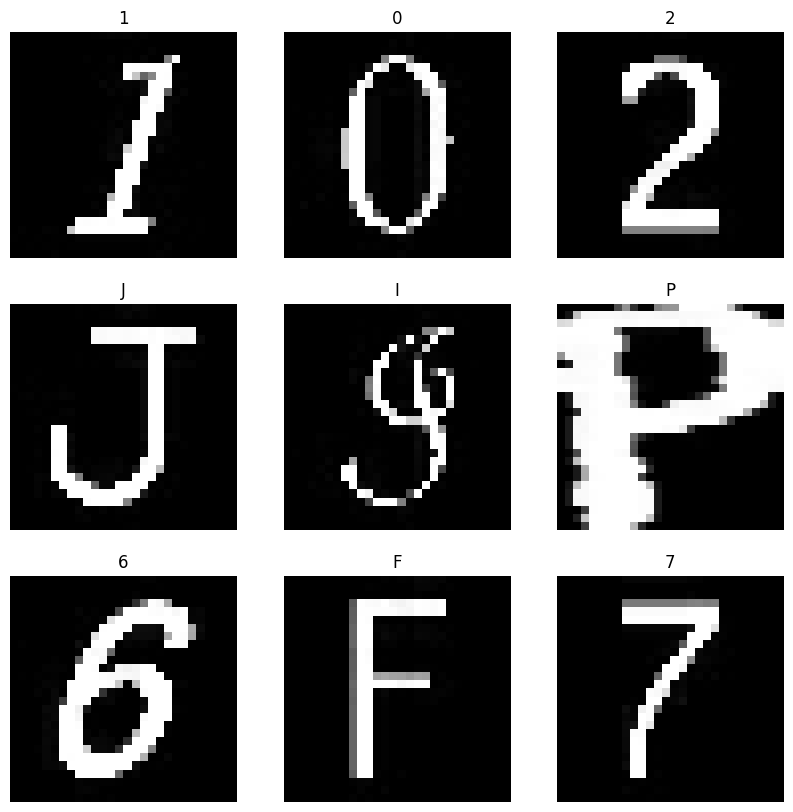

In [ ]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)

        plt.imshow(
            images[i].numpy().astype("uint8").squeeze(),
            cmap='gray'
        )

        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [ ]:
for kelas in class_names:
    jumlah = len(
        os.listdir(
            os.path.join(dataset_path, kelas)
        )
    )

    print(f"{kelas}: {jumlah}")

0: 1108
1: 1090
2: 1188
3: 1108
4: 1110
5: 1165
6: 1177
7: 1011
8: 1100
9: 1130
A: 1070
B: 1118
C: 1088
D: 1085
E: 1072
F: 1036
G: 1053
H: 1225
I: 1021
J: 1026
K: 1078
L: 544
M: 1035
N: 1048
O: 62
P: 1083
Q: 1027
R: 1053
S: 1035
T: 1026
U: 1061
V: 1045
W: 1018
X: 1050
Y: 1043
Z: 1045


In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

In [ ]:

def build_cnn_model():
    model = Sequential([
        # 1. Input Layer & Conv2D pertama (32 Filter)
        Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(28, 28, 1)), # Corrected input_shape
        MaxPooling2D((2, 2)),

        # 2. Conv2D kedua (64 Filter)
        Conv2D(64, (3, 3), padding='same', activation='relu'),
        MaxPooling2D((2, 2)),

        # 3. Flatten & Fully Connected Layer (Dense)
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),                      # Mencegah overfitting sesuai checklist

        # 4. Output Layer (36 Kelas untuk Karakter A-Z, 0-9)
        Dense(len(class_names), activation='softmax') # Using len(class_names) for dynamic class count
    ])

    return model

model = build_cnn_model()

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 36)             │         4,644 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 424,996 (1.62 MB)

 Trainable params: 424,996 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels.shape)

(32, 28, 28, 1)
(32,)


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
931/931 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.7102 - loss: 1.0446 - val_accuracy: 0.9157 - val_loss: 0.3192
Epoch 2/30
931/931 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8660 - loss: 0.4706 - val_accuracy: 0.9337 - val_loss: 0.2481
Epoch 3/30
931/931 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8962 - loss: 0.3605 - val_accuracy: 0.9431 - val_loss: 0.2077
Epoch 4/30
931/931 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9116 - loss: 0.3012 - val_accuracy: 0.9488 - val_loss: 0.1833
Epoch 5/30
931/931 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9200 - loss: 0.2676 - val_accuracy: 0.9545 - val_loss: 0.1713
Epoch 6/30
931/931 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9270 - loss: 0.2353 - val_accuracy: 0.9559 - val_loss: 0.1566
Epoch 7/30
931/931 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9355 - loss: 0.2087 - val_accuracy: 0.9602 - val_loss: 0.1400
Epoch 8/30
931/931 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9387 - loss: 0.1890 - val_accuracy:

In [ ]:
print(max(history.history['accuracy']))
print(max(history.history['val_accuracy']))

0.9776419997215271
0.9747515320777893


In [ ]:
model.evaluate(val_ds)

model.save("cnn_character_recognition.keras")

model.save(
    "/content/drive/MyDrive/anpr_viskom/cnn_character_recognition.keras"
)

233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9742 - loss: 0.1113


In [ ]:
history.history

{'accuracy': [0.710151731967926,
  0.8660198450088501,
  0.8961998224258423,
  0.9116422533988953,
  0.9200013279914856,
  0.9270175695419312,
  0.9355109333992004,
  0.9387001395225525,
  0.9439035654067993,
  0.9482342004776001,
  0.9519941210746765,
  0.9551497101783752,
  0.956291139125824,
  0.9609238505363464,
  0.963609516620636,
  0.9641130566596985,
  0.9658923149108887,
  0.9686450958251953,
  0.9683094024658203,
  0.9710957407951355,
  0.9725393056869507,
  0.9721028804779053,
  0.9731771349906921,
  0.9749899506568909,
  0.9754934906959534,
  0.9759634733200073,
  0.9776419997215271,
  0.9769706130027771],
 'loss': [1.0445795059204102,
  0.4705989956855774,
  0.36046096682548523,
  0.3012135326862335,
  0.26763540506362915,
  0.23534122109413147,
  0.20865868031978607,
  0.18896080553531647,
  0.1780988574028015,
  0.15659783780574799,
  0.14891909062862396,
  0.13694417476654053,
  0.13082432746887207,
  0.11759095638990402,
  0.11144397407770157,
  0.11084909737110138,
  

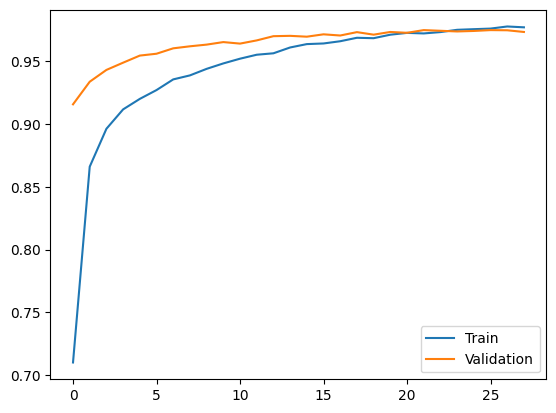

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.show()

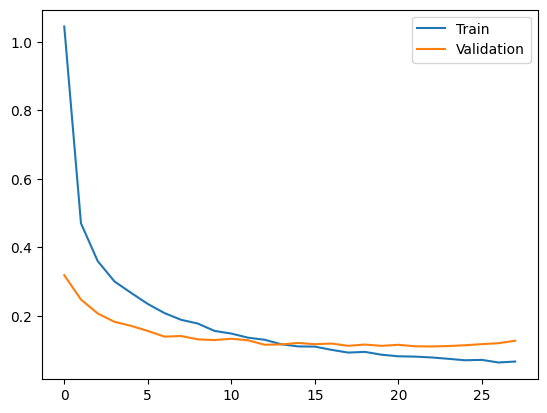

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train','Validation'])
plt.show()

In [ ]:
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[221   0   0 ...   0   0   0]
 [  0 217   0 ...   0   0   1]
 [  0   0 238 ...   0   0   2]
 ...
 [  0   0   0 ... 204   0   0]
 [  0   1   0 ...   0 198   0]
 [  0   0   4 ...   1   0 190]]


In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

           0       0.95      0.98      0.97       225
           1       1.00      0.97      0.98       223
           2       0.97      0.98      0.98       242
           3       0.98      0.99      0.99       205
           4       0.99      1.00      0.99       246
           5       0.99      0.98      0.99       241
           6       0.99      1.00      0.99       223
           7       0.98      0.99      0.99       200
           8       0.96      0.99      0.98       208
           9       0.98      1.00      0.99       250
           A       0.99      0.97      0.98       217
           B       0.99      0.98      0.98       213
           C       0.96      0.94      0.95       233
           D       0.99      0.98      0.99       197
           E       0.99      0.94      0.96       202
           F       1.00      0.98      0.99       222
           G       0.94      0.98      0.96       206
           H       0.97    

In [ ]:
misclassified = np.where(y_true != y_pred)[0]

print("Jumlah salah:", len(misclassified))

Jumlah salah: 192


In [ ]:
for idx in misclassified[:20]:
    print(
        f"Asli: {class_names[y_true[idx]]} | "
        f"Prediksi: {class_names[y_pred[idx]]}"
    )

Asli: D | Prediksi: 0
Asli: 0 | Prediksi: O
Asli: W | Prediksi: N
Asli: W | Prediksi: V
Asli: Q | Prediksi: L
Asli: 2 | Prediksi: Z
Asli: S | Prediksi: V
Asli: Y | Prediksi: V
Asli: O | Prediksi: 0
Asli: R | Prediksi: B
Asli: E | Prediksi: C
Asli: S | Prediksi: 4
Asli: R | Prediksi: M
Asli: P | Prediksi: R
Asli: M | Prediksi: H
Asli: B | Prediksi: S
Asli: V | Prediksi: N
Asli: M | Prediksi: W
Asli: I | Prediksi: 9
Asli: Z | Prediksi: 2


In [ ]:
cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

errors = []

for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm[i, j] > 0:
            errors.append(
                (
                    class_names[i],
                    class_names[j],
                    cm[i, j]
                )
            )

errors = sorted(
    errors,
    key=lambda x: x[2],
    reverse=True
)

print("Top 20 Kesalahan:")
for e in errors[:20]:
    print(f"{e[0]} -> {e[1]} : {e[2]}")

Top 20 Kesalahan:
C -> G : 10
E -> C : 8
O -> 0 : 5
Y -> V : 5
1 -> I : 4
Z -> 2 : 4
0 -> O : 3
E -> 8 : 3
G -> T : 3
M -> N : 3
P -> R : 3
S -> V : 3
2 -> Q : 2
2 -> Z : 2
5 -> S : 2
7 -> Y : 2
A -> M : 2
A -> N : 2
B -> R : 2
C -> B : 2
